# Sales order data exploration
Use this notebook to explore sales order data

In [2]:
df = spark.read.format("csv").option("header","false").load("Files/orders/2019.csv")
# df now is a Spark DataFrame containing CSV data from "Files/orders/2019.csv".
display(df)

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 4, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 980172c4-f788-4d67-b3cd-604bb9dcda25)

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 7, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, df612c42-da03-416c-8a2a-61b10355d54f)

# wildcard to read all the files in the orders folder

In [6]:
from pyspark.sql.types import *
order_schema = StructType([
    StructField("SalesOrderNumber",StringType()),
    StructField("SalesOrderLineNumber",IntegerType()),
    StructField("OrderDate", DateType()),
    StructField("CustomerName", StringType()),
    StructField("Email", StringType()),
    StructField("Item", StringType()),
    StructField("Quantity", IntegerType()),
    StructField("UnitPrice", FloatType()),
    StructField("Tax", FloatType())
])
df = spark.read.format("csv").schema(order_schema).load("Files/orders/*.csv")
display(df)

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 8, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 3ef5718b-42a1-4bb1-be39-c823b72f7cc9)

In [11]:
customers = df['CustomerName','Email']
print('total customer count' ,customers.count())
print('distinct customer count',customers.distinct().count())
print('distinct customer name',customers.distinct())

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 13, Finished, Available, Finished, False)

total customer count 32718
distinct customer count 12427
distinct customer name DataFrame[CustomerName: string, Email: string]


## another way to see customer

In [12]:
customers = df.select("CustomerName", "Email")

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 14, Finished, Available, Finished, False)

## some operations 

In [13]:
customers = df.select("CustomerName", "Email").where(df['Item']=='Road-250 Red, 52')
print(customers.count())
print(customers.distinct().count())

display(customers.distinct())

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 15, Finished, Available, Finished, False)

133
133


SynapseWidget(Synapse.DataFrame, 8ab464ba-9fbf-4211-bb4c-ac415b9b1987)

## Aggregate and group data in a DataFrame

In [14]:
productSales = df.select("Item", "Quantity").groupBy("Item").sum()

display(productSales)

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 16, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 7bf22d92-8ec7-4812-a45e-d9f53ea0e2b6)

In [18]:
from pyspark.sql.functions import *

yearlySales = df.select(year(col("OrderDate")).alias("Year")).groupBy("Year").count().orderBy("Year")
display(yearlySales)

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 20, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, cd8514fc-9bbc-43df-9dff-05b3bf49a8cd)

## DataFrame methods and functions to transform data

In [19]:
from pyspark.sql.functions import *

# Create Year and Month columns
transformed_df = df.withColumn("Year", year(col("OrderDate"))).withColumn("Month", month(col("OrderDate")))

# Create the new FirstName and LastName fields
transformed_df = transformed_df.withColumn("FirstName", split(col("CustomerName"), " ").getItem(0)).withColumn("LastName", split(col("CustomerName"), " ").getItem(1))

# Filter and reorder columns
transformed_df = transformed_df["SalesOrderNumber", "SalesOrderLineNumber", "OrderDate", "Year", "Month", "FirstName", "LastName", "Email", "Item", "Quantity", "UnitPrice", "Tax"]

# Display the first five orders
display(transformed_df.limit(5))

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 21, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, bd8fe4e4-edc5-478e-bc85-da51fd42cbc5)

## Save the transformed data


In [20]:
transformed_df.write.mode("overwrite").parquet('Files/transformed_data/orders')

print ("Transformed data saved!")

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 22, Finished, Available, Finished, False)

Transformed data saved!


In [22]:
orders_df = spark.read.format("parquet").load("Files/transformed_data/orders")
display(orders_df.limit(10))

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 24, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 147757df-15f0-4041-8f14-868be0db0a00)

## Save data in partitioned files

In [23]:
orders_df.write.partitionBy("Year","Month").mode("overwrite").parquet("Files/partitioned_data")

print ("Transformed data saved!")

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 25, Finished, Available, Finished, False)

Transformed data saved!


In [25]:
orders_2021_df = spark.read.format("parquet").load("Files/partitioned_data/Year=2021/Month=*")

display(orders_2021_df.limit(10))

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 27, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 7e769001-0c93-4ba4-a1e9-96c516424949)

## Create a table

In [26]:
 # Create a new table
 df.write.format("delta").saveAsTable("salesorders")

 # Get the table description
 spark.sql("DESCRIBE EXTENDED salesorders").show(truncate=False)

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 28, Finished, Available, Finished, False)

+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|col_name                    |data_type                                                                                                                                |comment|
+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|SalesOrderNumber            |string                                                                                                                                   |NULL   |
|SalesOrderLineNumber        |int                                                                                                                                      |NULL   |
|OrderDate                   |date                                                                                 

In [27]:
df = spark.sql("SELECT * FROM lakehouse_lab_3.dbo.salesorders LIMIT 10")

display(df)

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 29, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, bcb7c532-5b11-4f42-8dff-62c31b6e4703)

## Run SQL code in a cell

In [28]:
%%sql
SELECT YEAR(OrderDate) AS OrderYear,
       SUM((UnitPrice * Quantity) + Tax) AS GrossRevenue
FROM salesorders
GROUP BY YEAR(OrderDate)
ORDER BY OrderYear;

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 30, Finished, Available, Finished, False)

<Spark SQL result set with 3 rows and 2 fields>

## View results as a chart

In [29]:
%%sql
SELECT * FROM salesorders

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 31, Finished, Available, Finished, False)

<Spark SQL result set with 1000 rows and 9 fields>

## Get started with matplotlib

In [30]:
sqlQuery = "SELECT CAST(YEAR(OrderDate) AS CHAR(4)) AS OrderYear, \
                SUM((UnitPrice * Quantity) + Tax) AS GrossRevenue, \
                COUNT(DISTINCT SalesOrderNumber) AS YearlyCounts \
            FROM salesorders \
            GROUP BY CAST(YEAR(OrderDate) AS CHAR(4)) \
            ORDER BY OrderYear"
df_spark = spark.sql(sqlQuery)
df_spark.show()

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 33, Finished, Available, Finished, False)

+---------+--------------------+------------+
|OrderYear|        GrossRevenue|YearlyCounts|
+---------+--------------------+------------+
|     2019|   4172169.969970703|        1201|
|     2020|   6882259.268127441|        2733|
|     2021|1.1547835291696548E7|       12525|
+---------+--------------------+------------+



StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 36, Finished, Available, Finished, False)

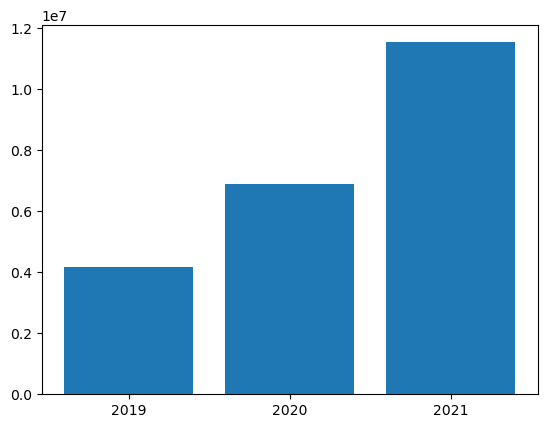

In [31]:
from matplotlib import pyplot as plt

# matplotlib requires a Pandas dataframe, not a Spark one
df_sales = df_spark.toPandas()

# Create a bar plot of revenue by year
plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'])

# Display the plot
plt.show()

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 39, Finished, Available, Finished, False)

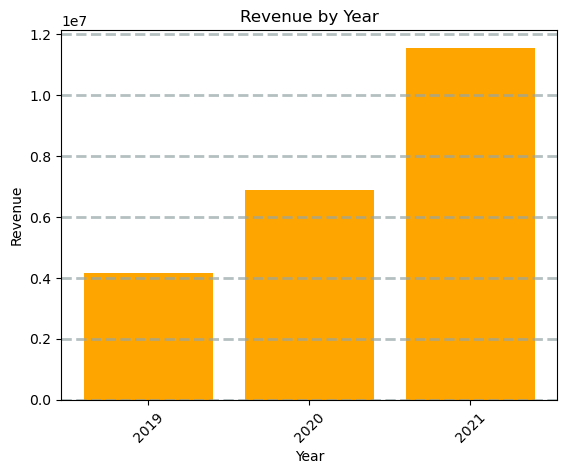

In [32]:
 from matplotlib import pyplot as plt

 # Clear the plot area
 plt.clf()

 # Create a bar plot of revenue by year
 plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')

 # Customize the chart
 plt.title('Revenue by Year')
 plt.xlabel('Year')
 plt.ylabel('Revenue')
 plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
 plt.xticks(rotation=45)

 # Show the figure
 plt.show()

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 42, Finished, Available, Finished, False)

<Figure size 640x480 with 0 Axes>

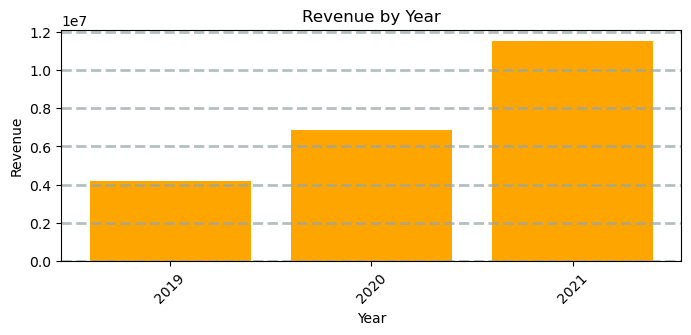

In [33]:
from matplotlib import pyplot as plt

# Clear the plot area
plt.clf()

# Create a Figure
fig = plt.figure(figsize=(8,3))

# Create a bar plot of revenue by year
plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')

# Customize the chart
plt.title('Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

# Show the figure
plt.show()

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 45, Finished, Available, Finished, False)

<Figure size 640x480 with 0 Axes>

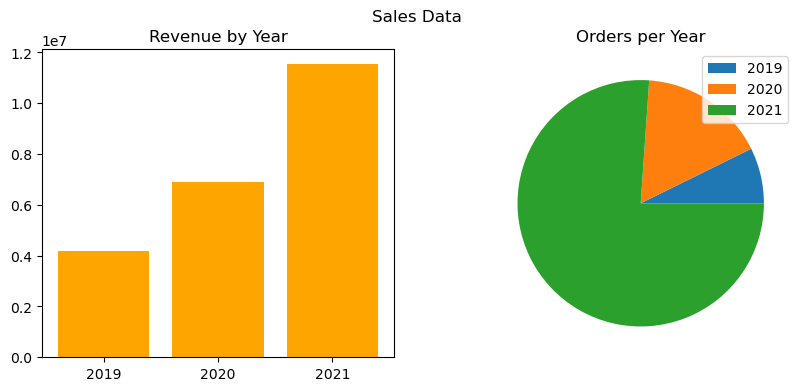

In [34]:
from matplotlib import pyplot as plt

# Clear the plot area
plt.clf()

# Create a figure for 2 subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize = (10,4))

# Create a bar plot of revenue by year on the first axis
ax[0].bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')
ax[0].set_title('Revenue by Year')

# Create a pie chart of yearly order counts on the second axis
ax[1].pie(df_sales['YearlyCounts'])
ax[1].set_title('Orders per Year')
ax[1].legend(df_sales['OrderYear'])

# Add a title to the Figure
fig.suptitle('Sales Data')

# Show the figure
plt.show()

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 48, Finished, Available, Finished, False)

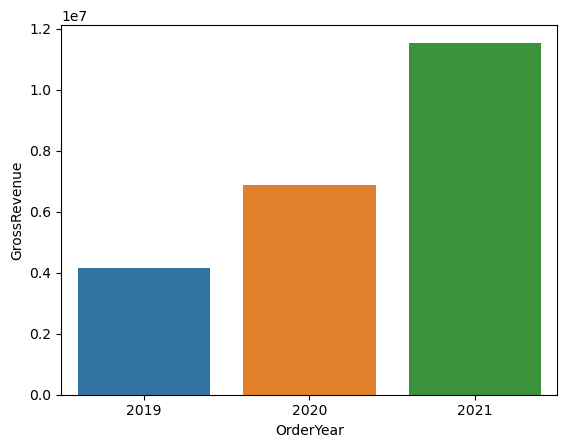

In [35]:
import seaborn as sns
import warnings

# Clear the plot area
plt.clf()

# Suppress FutureWarning from seaborn
warnings.filterwarnings('ignore', message='use_inf_as_na', category=FutureWarning)

# Create a bar chart
ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 51, Finished, Available, Finished, False)

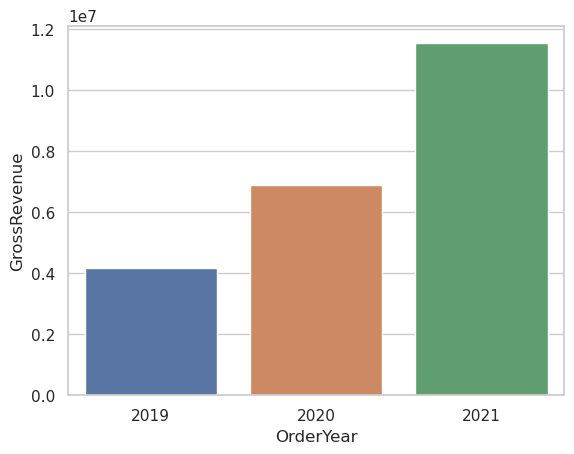

In [36]:
import seaborn as sns

# Clear the plot area
plt.clf()

# Set the visual theme for seaborn
sns.set_theme(style="whitegrid")

# Create a bar chart
ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, 3cfa1de4-0da4-4969-bca3-f15ca9e6b751, 54, Finished, Available, Finished, False)

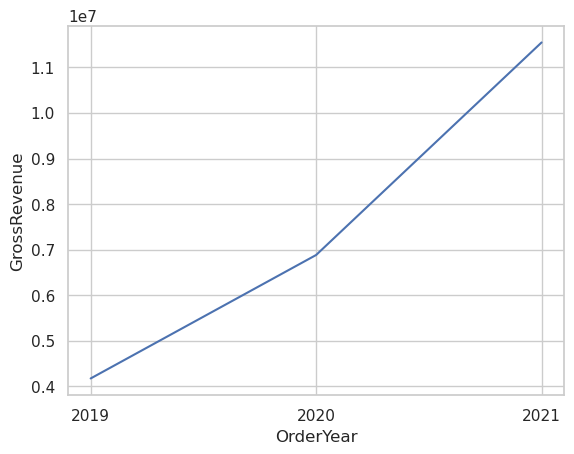

In [37]:
 import seaborn as sns

 # Clear the plot area
 plt.clf()

 # Create a line chart
 ax = sns.lineplot(x="OrderYear", y="GrossRevenue", data=df_sales)

 plt.show()